# Baseline CNN Model with Data Augmentation (Augmented Model)

We observed poor generalization with the Baseline Model, which was also likely overfitting to the training data. For image classification models, a good successor experiment would be to keep the same model architecture for now but apply data augmentation. This technique creates new training images by changing existing pictures through methods such as flipping and rotating. The goal is that, with augmented data, the model will generalize better to unseen images and reduce overfitting, while also improving its ability to correctly classify objects in new, unseen photos. This model will be referred to as the **Augmented Model** from now on.

The training data was augmented using random cropping, horizontal flipping, and rotation, while the validation and test sets remained unchanged. This ensures that validation and test performance is measured on the original data distribution, without introducing additional transformations that could affect the evaluation.

## Load Data

In [1]:
# Jupyter opens notebooks from the /waste-classification/notebooks directory, so we move to the project root.
%cd ..

/Users/rodrigomattos/Desktop/projects/waste-classification


In [2]:
from src.data import get_data, get_transform, get_transform_aug, get_datasets, get_dataloaders
import torch

In [3]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

In [4]:
transform = get_transform()
transform_aug = get_transform_aug()
dataset = get_data(transform)
dataset

Dataset ImageFolder
    Number of datapoints: 4817
    Root location: data/cnn_waste_classification
    StandardTransform
Transform: Compose(
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
               Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
           )

In [5]:
train_data, val_data, test_data = get_datasets(transform_aug, transform)

In [6]:
train_loader, val_loader, test_loader = get_dataloaders(train_data, val_data, test_data)

## Creating Model

In [7]:
from src.models import BaselineConvolutionalNetwork

In [8]:
augmented_model = BaselineConvolutionalNetwork()
augmented_model.load_state_dict(torch.load('models/02_aug_sgd_momentum50.pth'))

<All keys matched successfully>

In [9]:
augmented_model.to(device)

BaselineConvolutionalNetwork(
  (conv1): Conv2d(3, 6, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(6, 12, kernel_size=(3, 3), stride=(1, 1))
  (conv3): Conv2d(12, 24, kernel_size=(3, 3), stride=(1, 1))
  (conv4): Conv2d(24, 48, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=6912, out_features=90, bias=True)
  (fc2): Linear(in_features=90, out_features=9, bias=True)
)

## Evaluating Model

In [10]:
from src.evaluation import evaluate_model, create_confusion_matrix, inspecting_images

### - Validation Loss and Accuracy

In [11]:
loss, accuracy, all_labels, all_predictions = evaluate_model(augmented_model, val_loader)

In [12]:
print(f"Validation Loss: {loss:.4f}")
print(f"Accuracy: {accuracy:.2f}%")

Validation Loss: 1.2270
Accuracy: 57.12%


Given the validation loss of 1.2270 and accuracy of 57.12%, we can see a clear improvement on the Validation Loss with the Augmented Model compared to the Baseline Model. This indicates that the model was able reduce its overfitting, while improving marginally the accuracy. The 1.65 reduction in Validation Loss (from 2.8811 to 1.2270) is substantial enough to be considered a strong signal that the data augmentation improved the model generalization.

### - Confusion Matrix

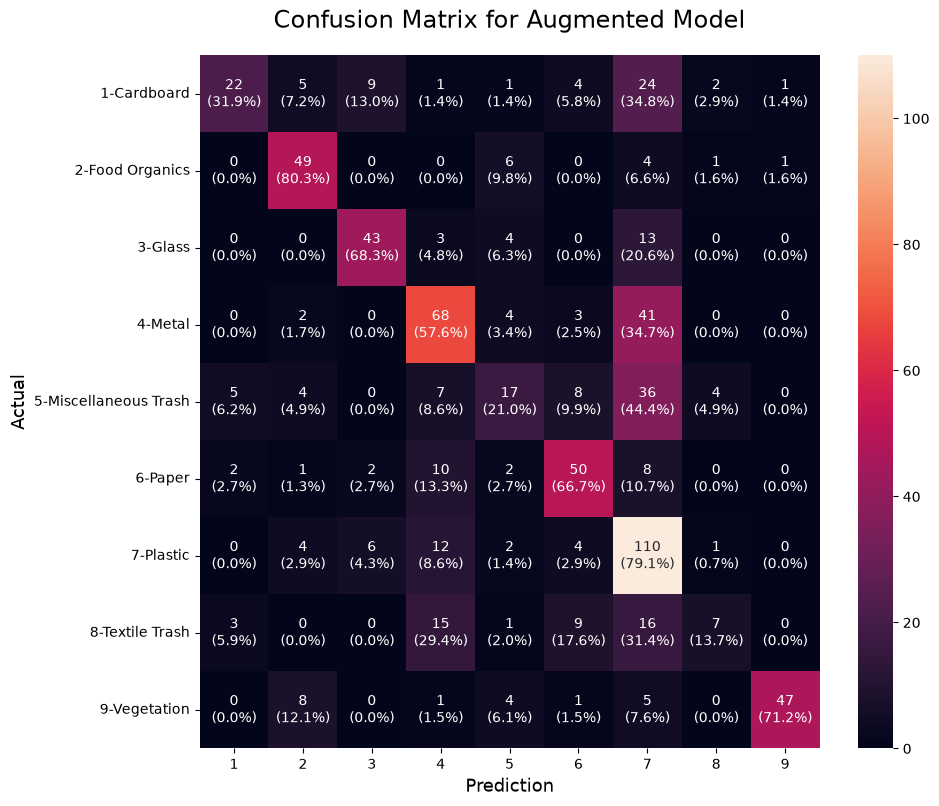

In [13]:
create_confusion_matrix(all_labels, all_predictions, dataset.classes, title="Confusion Matrix for Augmented Model")

**Confusion Matrix Insights:**

. A few classes achieved an accuracy of over 66%.

. Meanwhile, classes like Miscellaneous Trash and Textile Trash achieved very low accuracy (21% and 13.7%, respectively). Miscellaneous Trash was heavily confused by the model with Plastic, with 44.4% of true Miscellaneous Trash images being predicted as Plastic. Textile Trash was very inconsistent, with a high dispersion of predictions among the classes.

. The model predicted many objects as Plastic, probably because of the higher number of Plastic examples compared to other classes, alongside the model's improved generalization.

. The Vegetation class, which was a big surprise in the Baseline Model with an accuracy of 87.9%, dropped to 71.2%, probably as a consequence of the model's improved generalization. One possibility is that the model started to classify Vegetation examples as Food Organics, which can be considered a relatively reasonable confusion given the nature and visual similarity between the two classes.

### - Inspecting misclassified images

Found 41 4-Metal → 7-Plastic


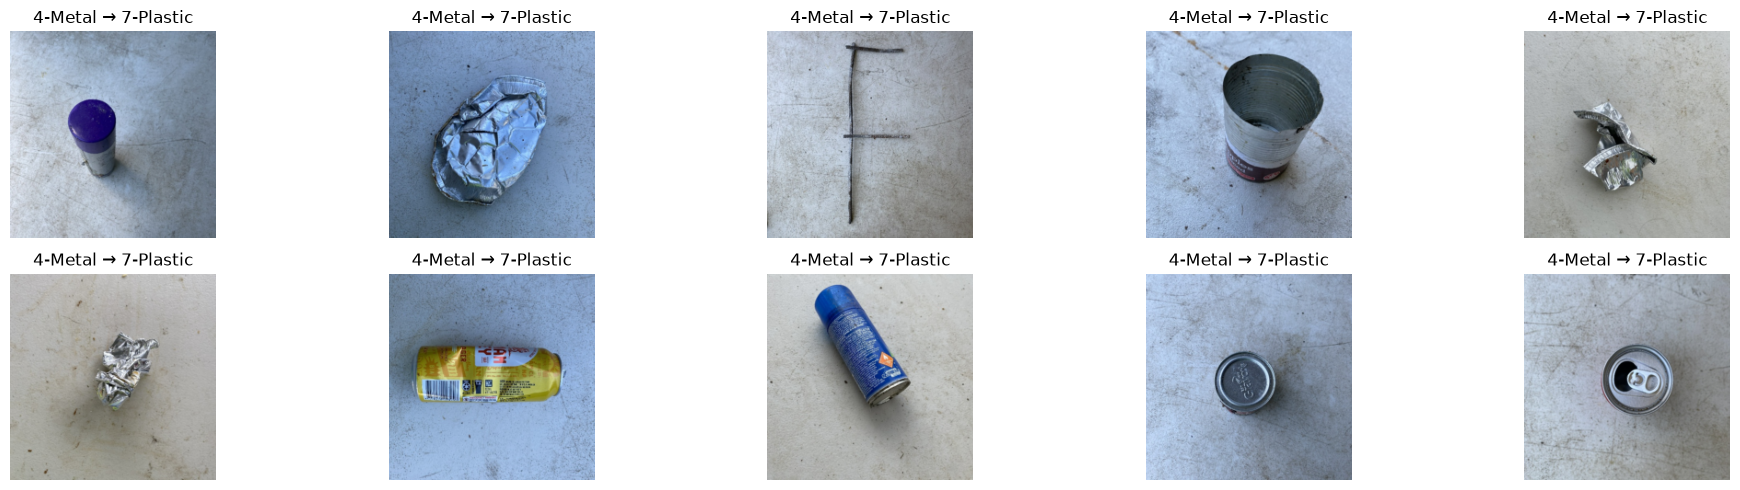

In [14]:
inspecting_images(dataset, val_data, all_labels, all_predictions, "4-Metal", "7-Plastic") # 41 errors

Found 36 5-Miscellaneous Trash → 7-Plastic


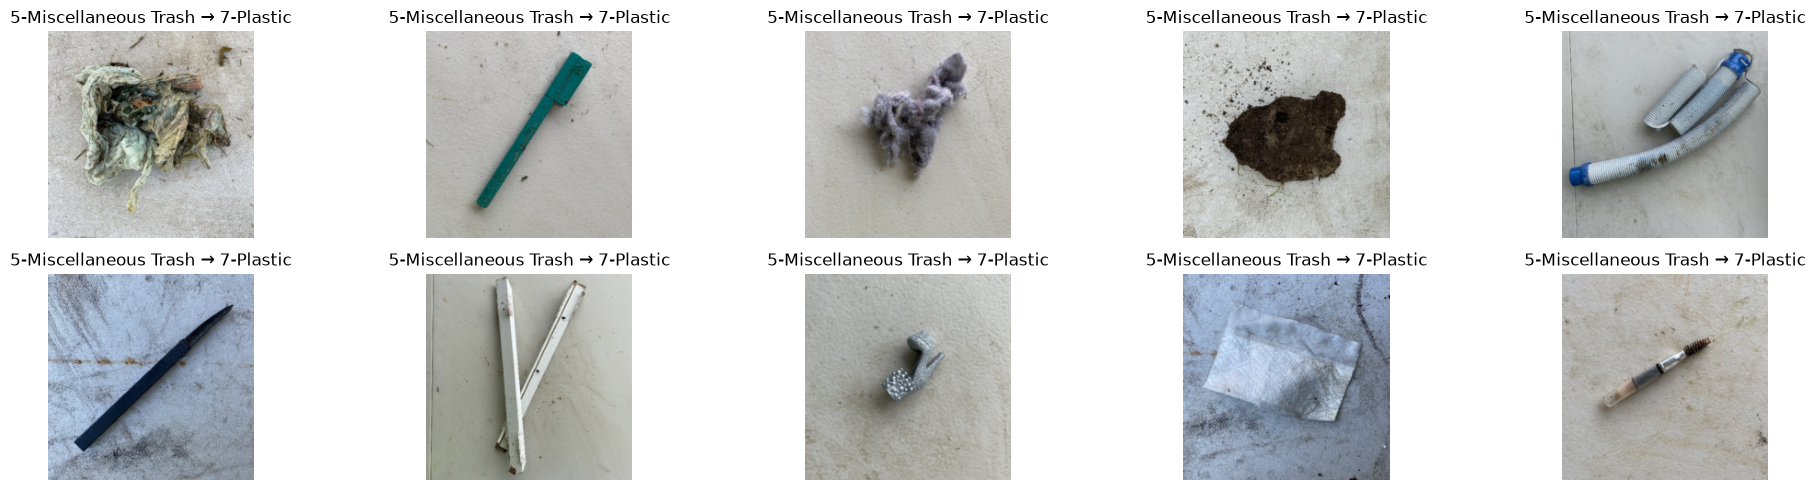

In [15]:
inspecting_images(dataset, val_data, all_labels, all_predictions, "5-Miscellaneous Trash", "7-Plastic") # 36 errors

Found 24 1-Cardboard → 7-Plastic


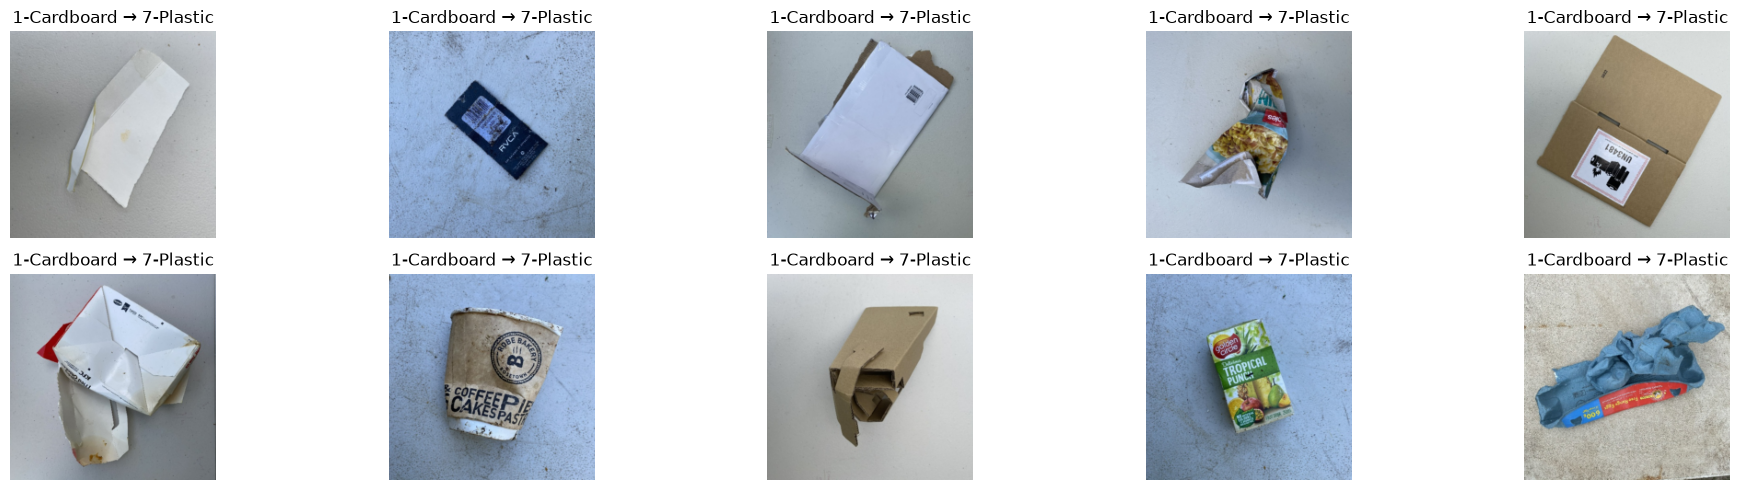

In [16]:
inspecting_images(dataset, val_data, all_labels, all_predictions, "1-Cardboard", "7-Plastic") # 24 errors

Found 8 9-Vegetation → 2-Food Organics


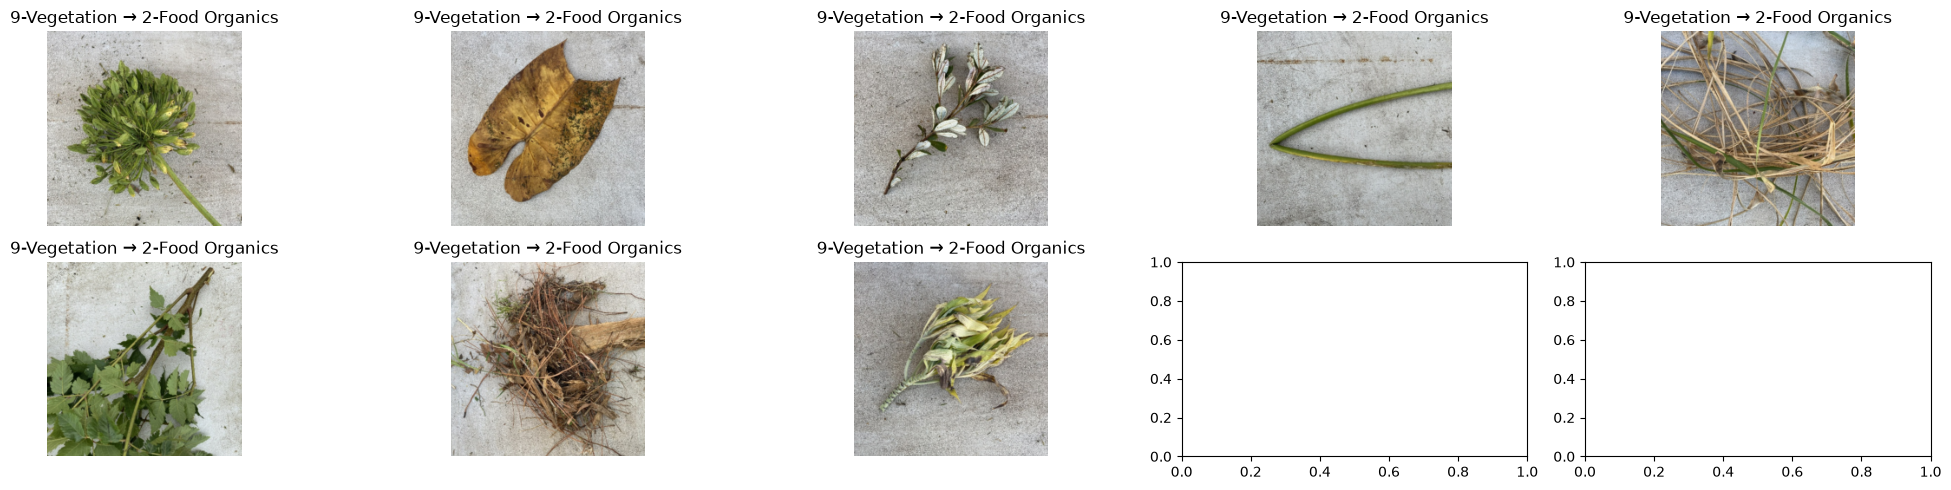

In [17]:
inspecting_images(dataset, val_data, all_labels, all_predictions, "9-Vegetation", "2-Food Organics") # 8 errors

**Misclassified Images Insights:**  

. Many different types of objects, such as aluminum foil and cardboard boxes, were misclassified as Plastic.
 
. The model classified a few Vegetation images as Food Organics, and their pictures show some characteristics that may have caused this confusion, such as their shape and colour.